# Predictors of destination non-alignment


In [1]:
from pathlib import Path
import sys

candidates = [Path.cwd(), Path.cwd() / "figure-reproduction", Path.cwd().parent]
repro_dir = next(
    (path.resolve() for path in candidates if (path / "src").is_dir() and (path / "data").is_dir()),
    None,
)
if repro_dir is None:
    raise FileNotFoundError("Run this notebook from the repository, figure-reproduction, or notebooks directory.")
sys.path.insert(0, str(repro_dir / "src"))

from figure_style import (
    DATA_DIR,
    OUTPUT_DIR,
    close_and_report,
    configure_style,
    figure_size,
    finish_axes,
    save_figure,
)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from matplotlib.colors import LinearSegmentedColormap, Normalize

EXPORT_PROFILE = "final"
configure_style(EXPORT_PROFILE)

data = pd.read_parquet(DATA_DIR / "non_alignment_shap_values.parquet")
data["feature_label"] = data["feature_label"].str.replace(r"\mathsf", r"\mathrm", regex=False)
metadata = (
    data[["feature", "feature_label", "feature_rank", "mean_abs_shap", "is_dependence"]]
    .drop_duplicates().sort_values("feature_rank")
)
feature_order = metadata["feature"].tolist()
label_order = metadata["feature_label"].tolist()
values = data.pivot(index="sample_id", columns="feature", values="feature_value")[feature_order]
shap_values = data.pivot(index="sample_id", columns="feature", values="shap_value")[feature_order]
custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#4C54E3", "#F2E1CD", "#F30486"], N=256
)


1 extra bytes in post.stringData array


rendered pixels: 1417 x 531
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_summary.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_summary.pdf


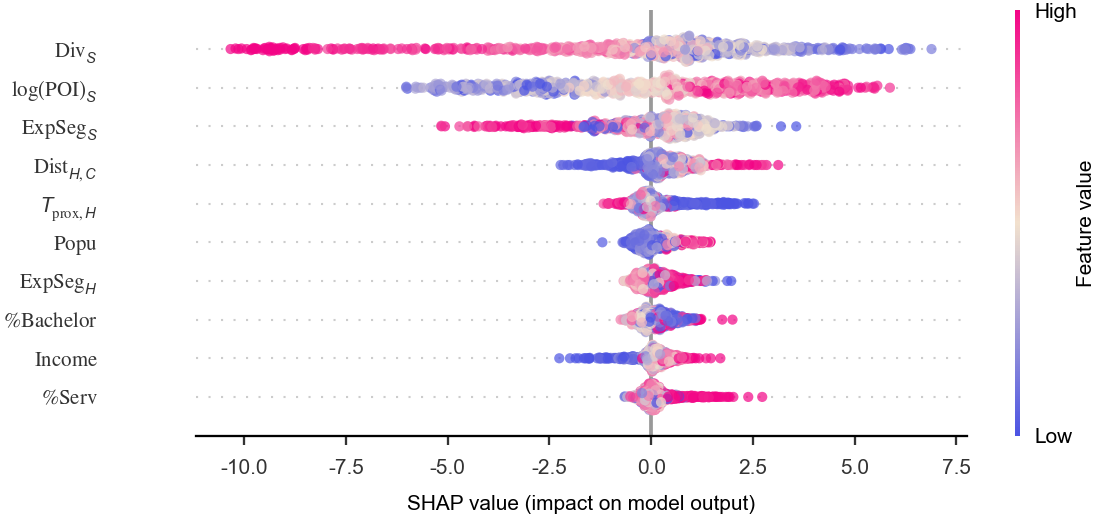

1 extra bytes in post.stringData array


rendered pixels: 531 x 449
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_feature_importance.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_feature_importance.pdf


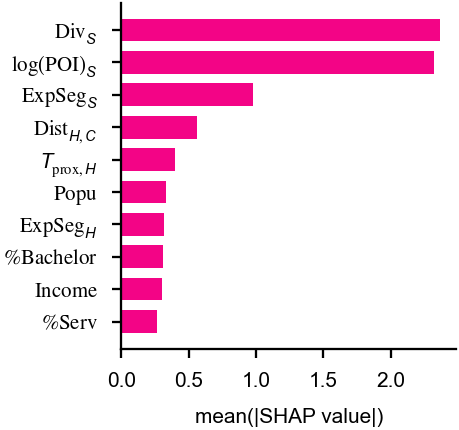

In [3]:
fig, ax = plt.subplots(figsize=figure_size("non_alignment_summary"))
fig.subplots_adjust(left=0.22, right=0.90, bottom=0.16, top=0.96)
explanation = shap.Explanation(
    values=shap_values.to_numpy(), data=values.to_numpy(), feature_names=label_order,
)
shap.plots.beeswarm(
    explanation, max_display=10, color=custom_cmap, alpha=0.7,
    s=6, plot_size=None, ax=ax, show=False,
)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=5)
ax.tick_params(axis="both", labelsize=5)
for label in ax.get_yticklabels():
    label.set_fontsize(5)
for extra_ax in [candidate for candidate in fig.axes if candidate is not ax]:
    extra_ax.tick_params(labelsize=5)
    extra_ax.yaxis.label.set_size(5)
    for text in extra_ax.texts:
        text.set_fontsize(5)
paths = save_figure(fig, "non_alignment_shap_summary", EXPORT_PROFILE)
close_and_report(fig, paths)

importance_fig, importance_ax = plt.subplots(figsize=figure_size("non_alignment_importance"))
importance_fig.subplots_adjust(left=0.34, right=0.97, bottom=0.20, top=0.97)
bar_data = metadata.sort_values("mean_abs_shap", ascending=True)
importance_ax.barh(np.arange(len(bar_data)), bar_data["mean_abs_shap"], color="#F30486", height=0.70)
importance_ax.set_yticks(np.arange(len(bar_data)), bar_data["feature_label"], fontsize=5)
importance_ax.set_xlabel("mean(|SHAP value|)", fontsize=5)
importance_ax.tick_params(axis="x", labelsize=5)
finish_axes(importance_ax)
paths = save_figure(importance_fig, "non_alignment_feature_importance", EXPORT_PROFILE)
close_and_report(importance_fig, paths)


1 extra bytes in post.stringData array


rendered pixels: 142 x 502
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_dependence_colourbar.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_dependence_colourbar.pdf


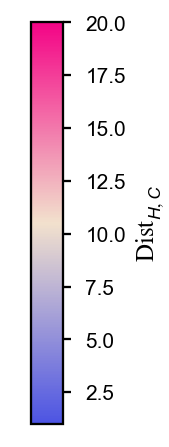

In [4]:
dependence = metadata[metadata["is_dependence"]].sort_values("feature_rank").reset_index(drop=True)
color_norm = Normalize(vmin=1, vmax=20)


def draw_dependence_panel(row, stem):
    fig, ax = plt.subplots(figsize=figure_size("non_alignment_dependence"))
    fig.subplots_adjust(left=0.19, right=0.97, bottom=0.16, top=0.95)
    subset = data[data["feature"].eq(row.feature)].sort_values("sample_id")
    x = subset["feature_value"].to_numpy()
    y = subset["shap_value"].to_numpy()
    color = subset["color_value"].to_numpy()
    limits = np.nanpercentile(x, [1, 99])
    ax.scatter(
        x, y, c=color, cmap=custom_cmap, norm=color_norm,
        s=4, alpha=0.7, edgecolors="none", rasterized=True,
    )
    ax.axhline(0, color="#aaaaaa", linewidth=0.55, linestyle=(0, (2, 3)))
    ax.set_xlim(*limits)
    ax.set_xlabel(row.feature_label)
    ax.set_ylabel("SHAP value")
    histogram = ax.twinx()
    counts, _, _ = histogram.hist(x, bins=20, range=limits, color="#dddddd", edgecolor="none", zorder=0)
    histogram.set_ylim(0, max(counts.max() * 10, 1))
    histogram.set_yticks([])
    histogram.spines["right"].set_visible(False)
    histogram.spines["top"].set_visible(False)
    histogram.patch.set_alpha(0)
    ax.set_zorder(histogram.get_zorder() + 1)
    ax.patch.set_alpha(0)
    paths = save_figure(fig, stem, EXPORT_PROFILE)
    close_and_report(fig, paths)


def draw_dependence_legend():
    fig, ax = plt.subplots(figsize=figure_size("non_alignment_colourbar"))
    fig.subplots_adjust(left=0.04, right=0.64, bottom=0.08, top=0.96)
    ax.set_axis_off()
    color_ax = fig.add_axes([0.24, 0.12, 0.22, 0.80])
    colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=color_norm, cmap=custom_cmap), cax=color_ax)
    colorbar.set_label(r"$\mathrm{Dist}_{H,C}$", labelpad=2)
    colorbar.ax.tick_params(labelsize=5, length=2)
    paths = save_figure(fig, "non_alignment_dependence_colourbar", EXPORT_PROFILE)
    close_and_report(fig, paths)


draw_dependence_legend()


rendered pixels: 591 x 502
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_poi_diversity.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_poi_diversity.pdf


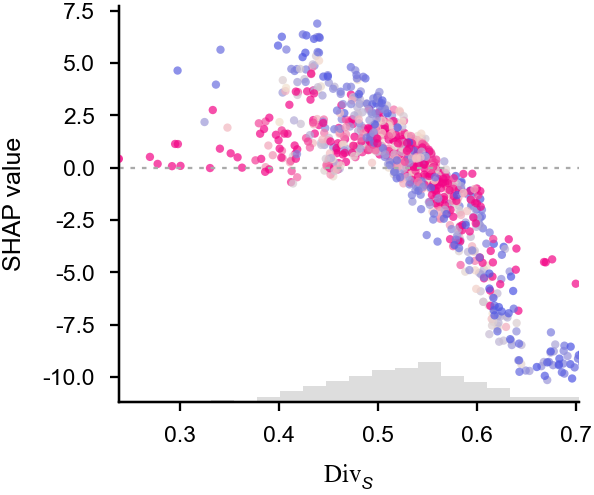

In [5]:
draw_dependence_panel(dependence.iloc[0], "non_alignment_shap_poi_diversity")


1 extra bytes in post.stringData array


rendered pixels: 591 x 502
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_poi_count.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_poi_count.pdf


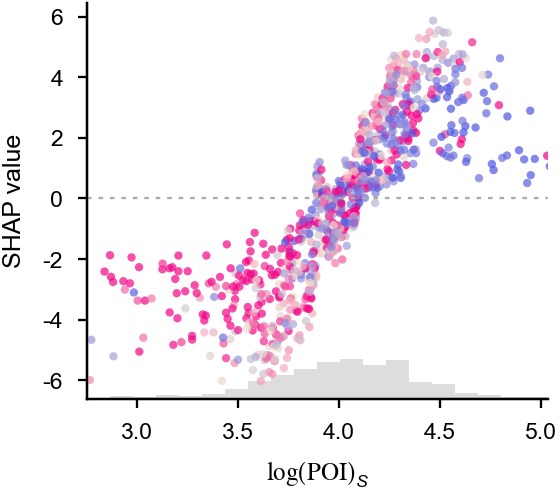

In [6]:
draw_dependence_panel(dependence.iloc[1], "non_alignment_shap_poi_count")


rendered pixels: 591 x 502
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_experienced_segregation.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_experienced_segregation.pdf


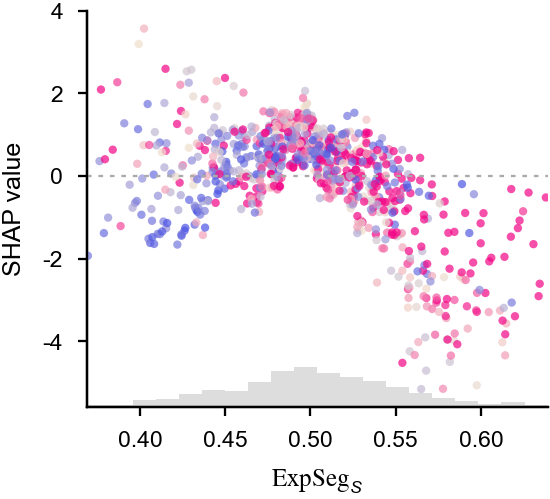

In [7]:
draw_dependence_panel(dependence.iloc[2], "non_alignment_shap_experienced_segregation")


1 extra bytes in post.stringData array


rendered pixels: 591 x 502
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_home_proximity.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/non_alignment_shap_home_proximity.pdf


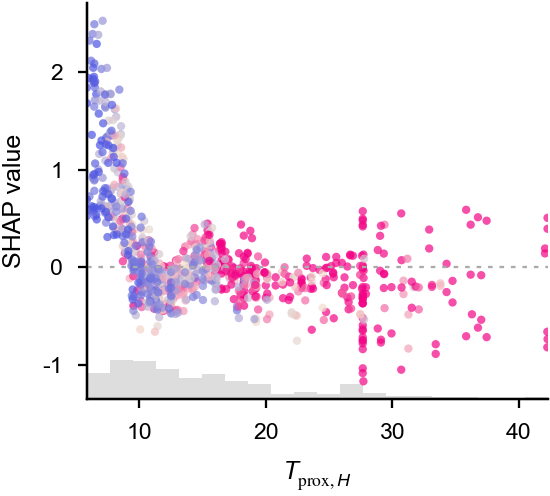

In [8]:
draw_dependence_panel(dependence.iloc[3], "non_alignment_shap_home_proximity")
